Loading data...
Pollution data loaded: 15 cities

Loading India states map...
Error loading states map: <urlopen error [WinError 10060] A connection attempt failed because the connected party did not properly respond after a period of time, or established connection failed because connected host has failed to respond>
Creating fallback base map geometry...
✓ Fallback base map created

Analyzing pollution levels...
Maximum PM2.5: 310
Minimum PM2.5: 45
Average PM2.5: 105.40

Creating pollution map with white Indian states...

✅ Map saved as 'india_pollution_map.png'


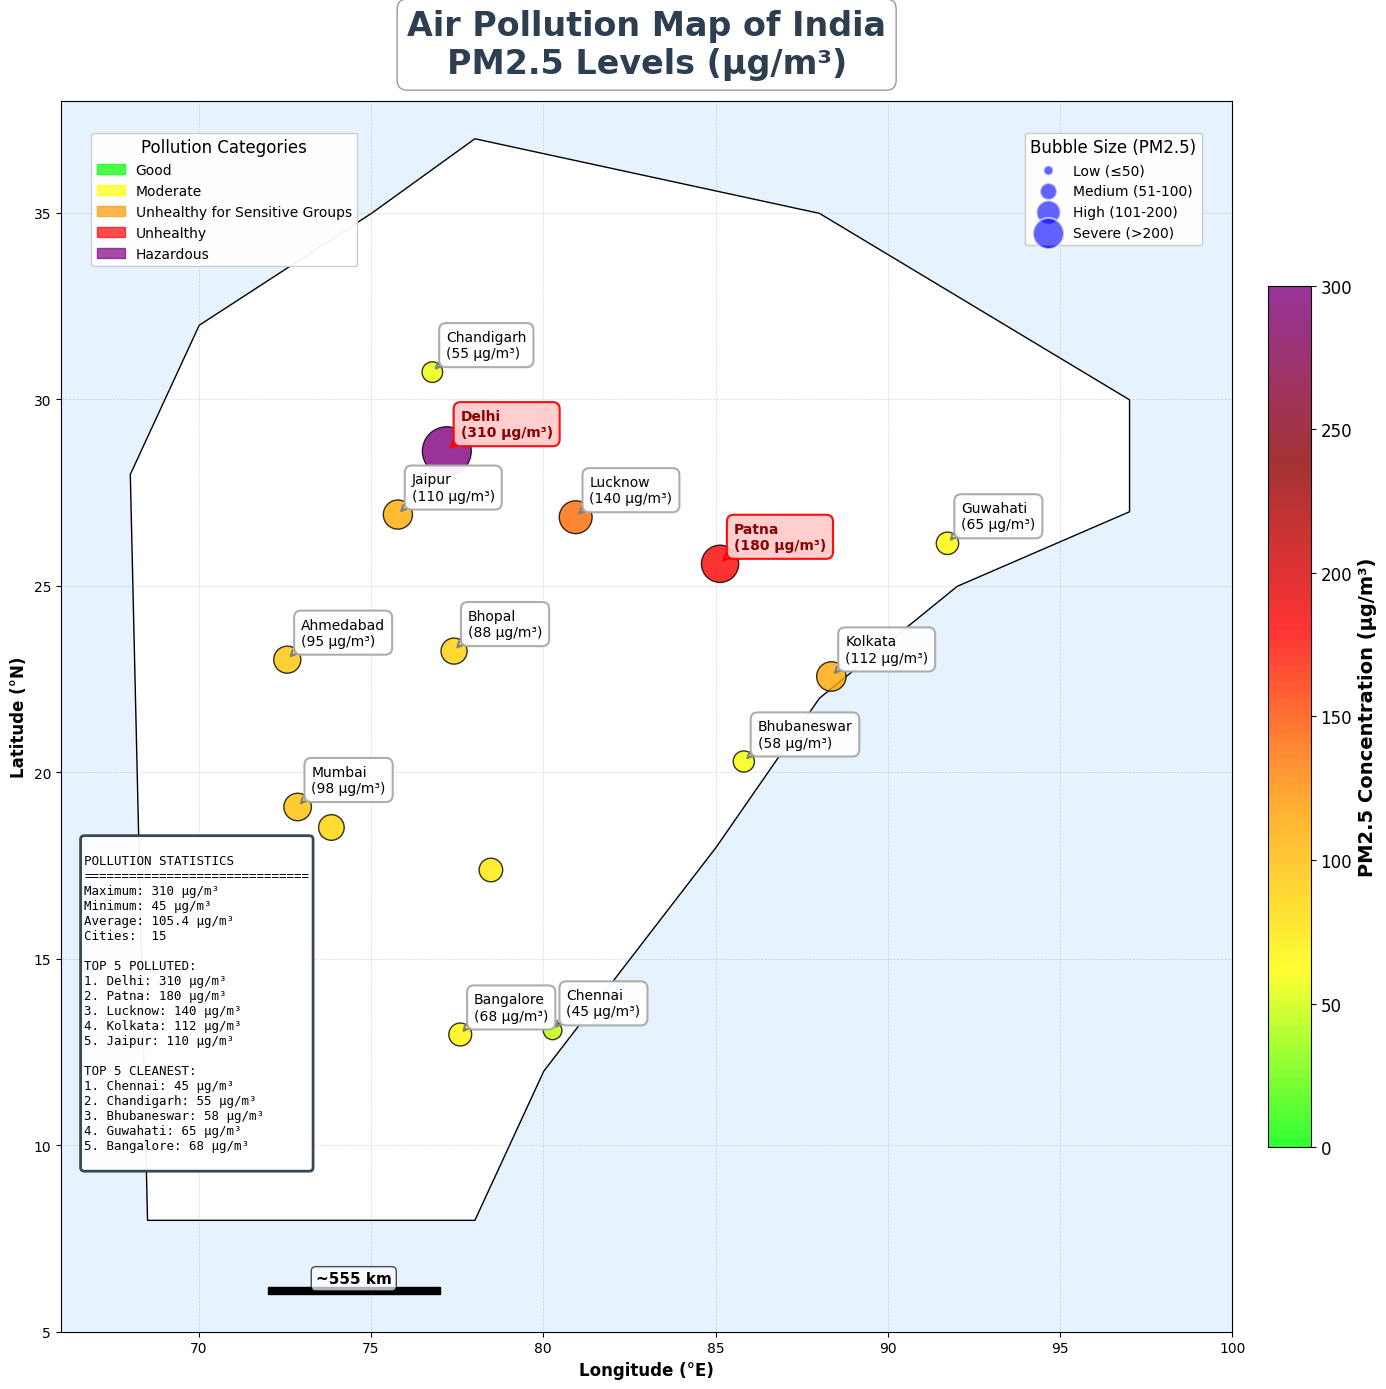


Creating pollution comparison chart...
✓ Statistics chart saved as 'pollution_statistics.png'

✅ India Pollution Map created successfully!

Files created:
1. india_pollution_map.png - Main map with India background
2. pollution_statistics.png - Statistical charts

To view the map, open the PNG file in any image viewer.


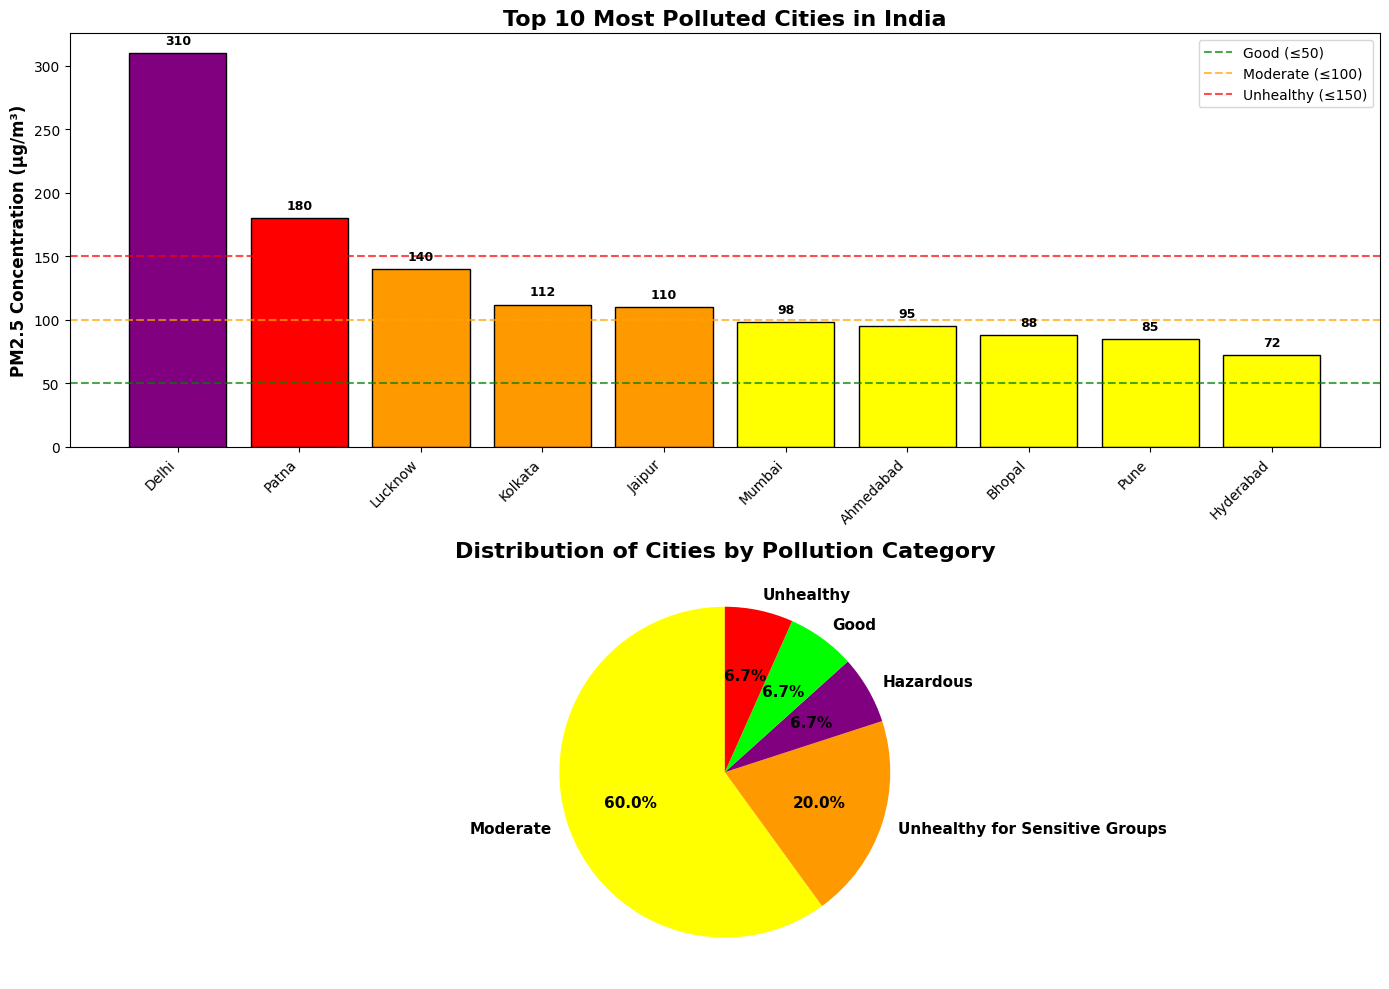

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import os
from shapely.geometry import Point, Polygon

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================

print("Loading data...")

# 1.1 Load pollution data
if not os.path.exists('pollution_data.csv'):
    print("Creating sample pollution data for Indian cities...")
    
    # Sample data for major Indian cities
    sample_data = {
        'City': ['Delhi', 'Mumbai', 'Kolkata', 'Chennai', 'Bangalore', 
                'Hyderabad', 'Ahmedabad', 'Pune', 'Jaipur', 'Lucknow',
                'Patna', 'Varanasi', 'Agra', 'Kanpur', 'Nagpur',
                'Indore', 'Bhopal', 'Chandigarh', 'Guwahati', 'Kochi'],
        'State': ['Delhi', 'Maharashtra', 'West Bengal', 'Tamil Nadu', 'Karnataka',
                 'Telangana', 'Gujarat', 'Maharashtra', 'Rajasthan', 'Uttar Pradesh',
                 'Bihar', 'Uttar Pradesh', 'Uttar Pradesh', 'Uttar Pradesh', 'Maharashtra',
                 'Madhya Pradesh', 'Madhya Pradesh', 'Punjab', 'Assam', 'Kerala'],
        'Latitude': [28.61, 19.07, 22.57, 13.08, 12.97,
                    17.38, 23.03, 18.52, 26.91, 26.85,
                    25.61, 25.32, 27.18, 26.45, 21.15,
                    22.72, 23.26, 30.73, 26.18, 9.93],
        'Longitude': [77.23, 72.87, 88.36, 80.27, 77.59,
                     78.47, 72.58, 73.86, 75.79, 80.94,
                     85.14, 82.97, 78.02, 80.33, 79.09,
                     75.87, 77.41, 76.78, 91.75, 76.26],
        'PM2.5': [210, 85, 120, 45, 38,
                  55, 92, 48, 110, 145,
                  165, 155, 175, 195, 52,
                  42, 47, 58, 62, 40]
    }
    
    pollution_df = pd.DataFrame(sample_data)
    pollution_df.to_csv('pollution_data.csv', index=False)
    print(f"Sample pollution data created with {len(pollution_df)} cities")
else:
    pollution_df = pd.read_csv('pollution_data.csv')
    print(f"Pollution data loaded: {len(pollution_df)} cities")

# ============================================
# PART 2: LOAD INDIA STATES GEOMETRY
# ============================================

print("\nLoading India states map...")

try:
    # Fetch a GeoJSON file containing Indian state boundaries
    geojson_url = "https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson"
    india_states = gpd.read_file(geojson_url)
    print("✓ India states map loaded successfully")
except Exception as e:
    print(f"Error loading states map: {e}")
    print("Creating fallback base map geometry...")
    # Fallback to a single polygon if internet fails
    india_coords = [
        (68.5, 8.0), (78.0, 8.0), (80.0, 12.0), (85.0, 18.0), 
        (88.0, 22.0), (92.0, 25.0), (97.0, 27.0), (97.0, 30.0),
        (88.0, 35.0), (78.0, 37.0), (75.0, 35.0), (70.0, 32.0),
        (68.0, 28.0), (68.5, 8.0)
    ]
    india_polygon = Polygon(india_coords)
    india_states = gpd.GeoDataFrame(geometry=[india_polygon], crs="EPSG:4326")
    print("✓ Fallback base map created")


# ============================================
# PART 3: ANALYZE POLLUTION DATA
# ============================================

print("\nAnalyzing pollution levels...")

# Calculate statistics
max_pollution = pollution_df['PM2.5'].max()
min_pollution = pollution_df['PM2.5'].min()
avg_pollution = pollution_df['PM2.5'].mean()

print(f"Maximum PM2.5: {max_pollution}")
print(f"Minimum PM2.5: {min_pollution}")
print(f"Average PM2.5: {avg_pollution:.2f}")

# Categorize pollution levels
def categorize_pollution(pm25):
    if pm25 <= 50:
        return 'Good'
    elif pm25 <= 100:
        return 'Moderate'
    elif pm25 <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 200:
        return 'Unhealthy'
    elif pm25 <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

pollution_df['Category'] = pollution_df['PM2.5'].apply(categorize_pollution)

# ============================================
# PART 4: CREATE MAP WITH WHITE STATES
# ============================================

print("\nCreating pollution map with white Indian states...")

# 4.1 Set up the figure and axis
fig, ax = plt.subplots(1, 1, figsize=(18, 14), facecolor='white')

# Set background color for the plot area (light blue to represent water)
ax.set_facecolor('#e6f3ff')

# 4.2 Define the geographic extent
lon_min, lon_max = 66, 100  # Longitude range
lat_min, lat_max = 5, 38     # Latitude range

# 4.3 Plot the states with WHITE fill and black borders
india_states.plot(ax=ax, color='white', edgecolor='black', linewidth=1, zorder=1)

# 4.4 Create a custom colormap for pollution levels
colors = ['#00ff00', '#ffff00', '#ff9900', '#ff0000', '#8b0000', '#800080']
custom_cmap = LinearSegmentedColormap.from_list('pollution_cmap', colors, N=100)

# 4.5 Plot cities with colors based on PM2.5 values
scatter = ax.scatter(
    pollution_df['Longitude'],
    pollution_df['Latitude'],
    c=pollution_df['PM2.5'],
    cmap=custom_cmap,
    s=pollution_df['PM2.5'] * 4,  # Size proportional to pollution
    alpha=0.8,
    edgecolors='black', # Changed to black to contrast with white states
    linewidth=1,
    vmin=0,
    vmax=300,
    zorder=5
)

# 4.6 Add city labels
# Only label major cities to avoid clutter
major_cities = pollution_df.nlargest(8, 'PM2.5')['City'].tolist() + \
               pollution_df.nsmallest(5, 'PM2.5')['City'].tolist()
major_cities = list(set(major_cities))

for idx, row in pollution_df.iterrows():
    if row['City'] in major_cities:
        # Adjust label position
        label_offset_x = 0.4
        label_offset_y = 0.4
        
        # Style based on pollution level
        if row['PM2.5'] > 150:
            bbox_color = '#ffcccc'
            text_color = 'darkred'
            fontweight = 'bold'
        else:
            bbox_color = 'white'
            text_color = 'black'
            fontweight = 'normal'
        
        ax.annotate(
            f"{row['City']}\n({row['PM2.5']} μg/m³)",
            xy=(row['Longitude'], row['Latitude']),
            xytext=(row['Longitude'] + label_offset_x, row['Latitude'] + label_offset_y),
            fontsize=10,
            fontweight=fontweight,
            color=text_color,
            bbox=dict(boxstyle="round,pad=0.5", facecolor=bbox_color, alpha=0.95,
                     edgecolor='darkgray' if row['PM2.5'] <= 150 else 'red',
                     linewidth=1.5),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2",
                          color='gray' if row['PM2.5'] <= 150 else 'red',
                          linewidth=1.5),
            zorder=6
        )

# ============================================
# PART 5: CUSTOMIZE THE MAP
# ============================================

# 5.1 Set map boundaries
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# 5.2 Add title
plt.title('Air Pollution Map of India\nPM2.5 Levels (μg/m³)', 
          fontsize=24, fontweight='bold', pad=20, color='#2c3e50',
          bbox=dict(boxstyle="round", facecolor='white', alpha=0.8, edgecolor='gray'))

# 5.3 Add axis labels
ax.set_xlabel('Longitude (°E)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude (°N)', fontsize=12, fontweight='bold')

# 5.4 Add colorbar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('PM2.5 Concentration (μg/m³)', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# 5.5 Add legends
category_colors = {
    'Good': '#00ff00',
    'Moderate': '#ffff00',
    'Unhealthy for Sensitive Groups': '#ff9900',
    'Unhealthy': '#ff0000',
    'Very Unhealthy': '#8b0000',
    'Hazardous': '#800080'
}

# Pollution category legend
legend_elements = []
for category, color in category_colors.items():
    if category in pollution_df['Category'].values:
        legend_elements.append(mpatches.Patch(color=color, label=category, alpha=0.7))

# Size legend
size_elements = [
    plt.scatter([], [], s=50, c='blue', alpha=0.6, label='Low (≤50)', 
                edgecolors='white', linewidth=1.5),
    plt.scatter([], [], s=150, c='blue', alpha=0.6, label='Medium (51-100)', 
                edgecolors='white', linewidth=1.5),
    plt.scatter([], [], s=300, c='blue', alpha=0.6, label='High (101-200)', 
                edgecolors='white', linewidth=1.5),
    plt.scatter([], [], s=500, c='blue', alpha=0.6, label='Severe (>200)', 
                edgecolors='white', linewidth=1.5)
]

# Position legends
legend1 = ax.legend(handles=legend_elements, title='Pollution Categories',
                   loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=10,
                   title_fontsize=12, framealpha=0.95, facecolor='white')

legend2 = ax.legend(handles=size_elements, title='Bubble Size (PM2.5)',
                   loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=10,
                   title_fontsize=12, framealpha=0.95, facecolor='white')

ax.add_artist(legend1)
ax.add_artist(legend2)

# 5.6 Add statistics box
top_5 = pollution_df.nlargest(5, 'PM2.5')
bottom_5 = pollution_df.nsmallest(5, 'PM2.5')

stats_text = f"""
POLLUTION STATISTICS
{'='*30}
Maximum: {max_pollution} μg/m³
Minimum: {min_pollution} μg/m³
Average: {avg_pollution:.1f} μg/m³
Cities:  {len(pollution_df)}

TOP 5 POLLUTED:
{chr(10).join([f"{i+1}. {row['City']}: {row['PM2.5']} μg/m³" for i, (_, row) in enumerate(top_5.iterrows())])}

TOP 5 CLEANEST:
{chr(10).join([f"{i+1}. {row['City']}: {row['PM2.5']} μg/m³" for i, (_, row) in enumerate(bottom_5.iterrows())])}
"""

plt.text(0.02, 0.40, stats_text, transform=ax.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round", facecolor='white', alpha=0.95,
                  edgecolor='#2c3e50', linewidth=2))

# 5.7 Add scale bar
from matplotlib.patches import Rectangle
scale_bar_length = 5
scale_bar = Rectangle((72, 6), scale_bar_length, 0.2, facecolor='black', edgecolor='black')
ax.add_patch(scale_bar)
ax.text(72 + scale_bar_length/2, 6.3, f'~{int(scale_bar_length*111)} km',
        fontsize=11, ha='center', fontweight='bold', 
        bbox=dict(boxstyle="round", facecolor='white', alpha=0.7))

# 5.8 Add north arrow
arrow_x, arrow_y = 95, 36
arrow_length = 1.0
arrow = plt.Polygon([(arrow_x, arrow_y), 
                     (arrow_x-0.3, arrow_y-0.8),
                     (arrow_x+0.3, arrow_y-0.8)], 
                    facecolor='black', edgecolor='black')
ax.add_patch(arrow)
ax.text(arrow_x, arrow_y+0.3, 'N', fontsize=14, fontweight='bold', ha='center')

# 5.9 Add gridlines
ax.grid(True, linestyle='--', alpha=0.3, color='gray', linewidth=0.5)

# ============================================
# PART 6: SAVE AND DISPLAY
# ============================================

# 6.1 Save the map
output_filename = 'india_pollution_map.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white',
            edgecolor='none', pad_inches=0.5)
print(f"\n✅ Map saved as '{output_filename}'")

# 6.2 Display the map
plt.tight_layout()
plt.show()

# ============================================
# PART 7: CREATE SIMPLE BAR CHART
# ============================================

print("\nCreating pollution comparison chart...")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Bar chart of top 10 polluted cities
top10 = pollution_df.nlargest(10, 'PM2.5')
colors_bars = [category_colors[categorize_pollution(x)] for x in top10['PM2.5']]
bars = ax1.bar(range(len(top10)), top10['PM2.5'], color=colors_bars, 
               edgecolor='black', linewidth=1)
ax1.set_xticks(range(len(top10)))
ax1.set_xticklabels(top10['City'], rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Most Polluted Cities in India', fontsize=16, fontweight='bold')

# Add value labels
for bar, val in zip(bars, top10['PM2.5']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add threshold lines
ax1.axhline(y=50, color='green', linestyle='--', alpha=0.7, label='Good (≤50)')
ax1.axhline(y=100, color='orange', linestyle='--', alpha=0.7, label='Moderate (≤100)')
ax1.axhline(y=150, color='red', linestyle='--', alpha=0.7, label='Unhealthy (≤150)')
ax1.legend(loc='upper right')

# Pie chart of pollution categories
category_counts = pollution_df['Category'].value_counts()
colors_dist = [category_colors[cat] for cat in category_counts.index]
wedges, texts, autotexts = ax2.pie(category_counts.values, 
                                    labels=category_counts.index,
                                    colors=colors_dist,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Distribution of Cities by Pollution Category', fontsize=16, fontweight='bold')

# Improve pie chart labels
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('pollution_statistics.png', dpi=300, bbox_inches='tight')
print("✓ Statistics chart saved as 'pollution_statistics.png'")

# ============================================
# FINAL OUTPUT
# ============================================

print("\n" + "="*50)
print("✅ India Pollution Map created successfully!")
print("="*50)
print("\nFiles created:")
print(f"1. {output_filename} - Main map with India background")
print("2. pollution_statistics.png - Statistical charts")
print("\nTo view the map, open the PNG file in any image viewer.")